# 使用path_map
使用path_map的用法， 起一个名字，不一定是节点的名称， 可以起别的名字，表示整个节点，  path_map要和path配合起来使用

{'topic': '猫咪', 'poem': '## 《它跃过一炷香的时辰》\n\n在瓷碗边沿，它弓起腰身\n像一段被遗弃的绳索忽然有了\n丝绸的命脉。瞳孔里\n一尾干涸的鱼正浮出瓦蓝的深井\n\n呼噜声在沙发折痕里结网\n捕食白昼坠落的碎屑。偶尔抬头\n用胡须丈量光柱的直径——\n这个动作让它比春天更薄\n\n我数着它脚垫的印痕\n数到第七朵梅花时，黄昏\n正从窗帘褶皱里洇出。而它早已\n伸个懒腰，将我的时辰卷成线团\n\n当夜色从它脊背滑落\n整座房间都是它留下的半枚月亮。我', 'content_type': '诗'}
-----------------
{'topic': '猫咪', 'joke': '一只猫走进咖啡馆，对店员说：“我要一杯拿铁，拉花要鱼形的。”\n\n店员惊讶道：“天哪！你会说话？！”\n\n猫淡定地舔舔爪子：“别大惊小怪。我们猫本来就会说话，只是平时懒得理你们人类。”\n\n店员颤抖着端来咖啡，猫喝了一口，皱眉：“这奶泡打得不行，拉花也不像鱼，像条死虫子。”\n\n店员委屈：“您要求也太高了吧……”\n\n猫叹了口气，放下杯子，从口袋里掏出一只死老鼠拍在桌上：“算了，用这个结账，不用找了。”\n\n店员崩溃：“这……这不行啊！”\n\n猫瞪大眼睛：“怎么不行？你们人类不是天天说‘猫粮换咖啡，天经地义’吗？”\n\n店员刚想反驳，猫突然跳下椅子，回头甩了一句：“记住，下次拉花要像三文鱼，不然我就去隔壁狗咖啡厅投诉你。”\n\n说完，它优雅地走出门，消失在街角，只留下店员对着死老鼠发呆。\n\n——后来那只猫再也没来过，但店员总在深夜梦见一只猫举着鱼形拉花，幽幽地说：“你欠我一条鱼。”', 'content_type': '笑话'}


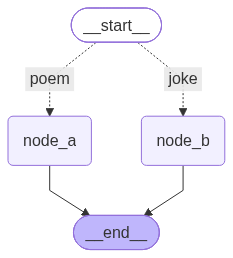

In [2]:
# 例子，先写使用path_map，等下再写不写path_map

from dotenv import load_dotenv
load_dotenv(override=True) # 如果有其他名称， 去覆盖
from langchain_deepseek import ChatDeepSeek
from typing import TypedDict,Annotated,Literal
from langgraph.graph import StateGraph,START,END
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

# 2. 定义节点
def node_a(state:OverAllState) -> OverAllState:
    poem = model.invoke(f"写一首关于{state['topic']}主题的诗").content
    return {
        "poem": poem
    }

def node_b(state:OverAllState) -> OverAllState:
    joke = model.invoke(f"写一个关于{state['topic']}的笑话").content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["poem", "joke"]: # 如果返回指代节点，就必须写node_a和node_b
    if "诗" in state["content_type"]:
        return "poem"
    else:
        return "joke"


# 3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)

# 改成并行
builder.add_conditional_edges(START, my_route, path_map={
    "poem": "node_a", # value必须是节点的名称， poem这些随便填写
    "joke": "node_b"
})
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

graph = builder.compile()
poem_res = graph.invoke({"topic":"猫咪","content_type":"诗"})
print(poem_res)

print("-----------------")

joke_res = graph.invoke({"topic":"猫咪","content_type":"笑话"})
print(joke_res)

display(graph) # 整体没有区别，多了显示poem和joke的名称，一般在下面，路由显示多个节点，会有区别
